# Unsupervised Learning on Sentinel‑3 Altimetry data

This notebook classifies Sentinel-3 radar echoes into **sea ice** and **leads** using unsupervised learning methods — K-Means and Gaussian Mixture Models (GMM).  
We evaluate our classifications against ESA's official labels and generate echo statistics for each class.

By the end, you should be able to :
- Cluster altimetry echoes
- Visualise average echo shapes
- Benchmark against ESA classification

#  Preparing Our Workspace

In [1]:
# Mount Google Drive to access files

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Install libraries for working with scientific data formats
!pip install rasterio
!pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 103.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 75.0 MB/s eta 0:00:00


# Unsupervised Learning: Clustering Echoes

Unsupervised learning finds hidden structure in unlabeled data. We'll use two clustering algorithms:
- **K-means**: assigns each point to the nearest cluster center.
- **GMM**: fits a probability distribution over the data for soft clustering.



## Basic Clustering Examples (Synthetic Data)


### K-means Clustering (Toy Example)

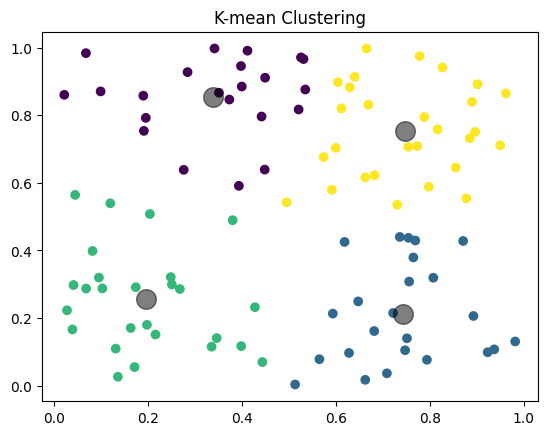

In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# Sample data
X = np.random.rand(100, 2)

# K-means model
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

# Plotting
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)
plt.title('K-mean Clustering')
plt.show()


### GMM Clustering (Toy Example)

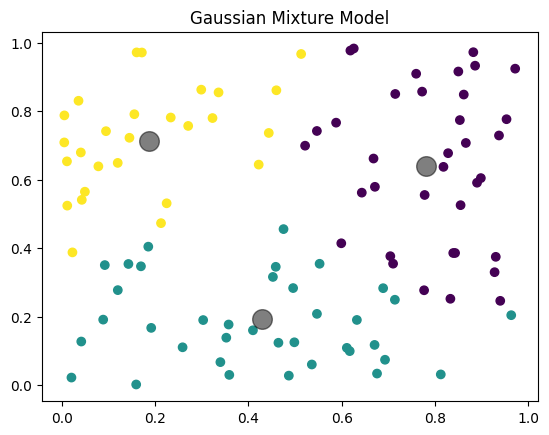

In [11]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import numpy as np

# Sample data
X = np.random.rand(100, 2)

# GMM model
gmm = GaussianMixture(n_components=3)
gmm.fit(X)
y_gmm = gmm.predict(X)

# Plotting
plt.scatter(X[:, 0], X[:, 1], c=y_gmm, cmap='viridis')
centers = gmm.means_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)
plt.title('Gaussian Mixture Model')
plt.show()

# Application: Image Classification (Sentinel‑2)

We apply both clustering methods to Sentinel‑2 RGB band imagery to distinguish between sea ice and leads based on pixel intensity values.

## Apply K-Means to Sentinel-2 Data


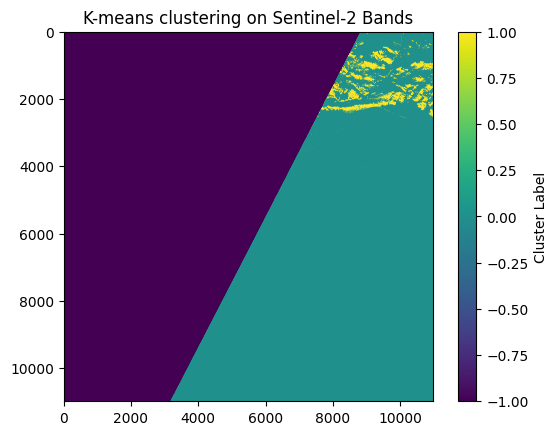

In [8]:
import rasterio
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

base_path = "/content/drive/MyDrive/Earth Science/GEOL0069/Week 4/Unsupervised Learning/S2A_MSIL1C_20190301T235611_N0207_R116_T01WCU_20190302T014622.SAFE/GRANULE/L1C_T01WCU_A019275_20190301T235610/IMG_DATA/" # You need to specify the path
bands_paths = {
    'B4': base_path + 'T01WCU_20190301T235611_B04.jp2',
    'B3': base_path + 'T01WCU_20190301T235611_B03.jp2',
    'B2': base_path + 'T01WCU_20190301T235611_B02.jp2'
}

# Read and stack the band images
band_data = []
for band in ['B4']:
    with rasterio.open(bands_paths[band]) as src:
        band_data.append(src.read(1))

# Stack bands and create a mask for valid data (non-zero values in all bands)
band_stack = np.dstack(band_data)
valid_data_mask = np.all(band_stack > 0, axis=2)

# Reshape for K-means, only including valid data
X = band_stack[valid_data_mask].reshape((-1, 1))

# K-means clustering
kmeans = KMeans(n_clusters=2, random_state=0).fit(X)
labels = kmeans.labels_

# Create an empty array for the result, filled with a no-data value (e.g., -1)
labels_image = np.full(band_stack.shape[:2], -1, dtype=int)

# Place cluster labels in the locations corresponding to valid data
labels_image[valid_data_mask] = labels

# Plotting the result
plt.imshow(labels_image, cmap='viridis')
plt.title('K-means clustering on Sentinel-2 Bands')
plt.colorbar(label='Cluster Label')
plt.show()

del kmeans, labels, band_data, band_stack, valid_data_mask, X, labels_image

### Apply GMM to Sentinel-2 Data

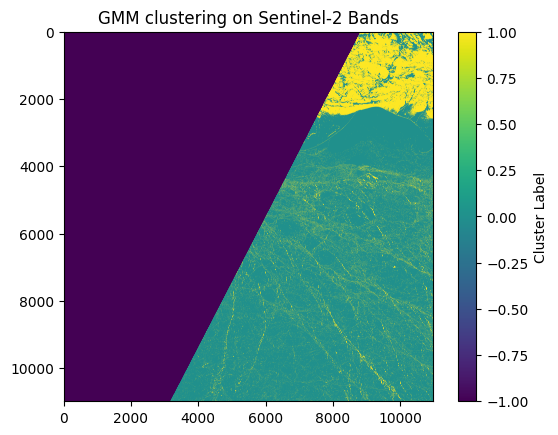

In [12]:
import rasterio
import numpy as np
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# Paths to the band images
base_path = "/content/drive/MyDrive/Earth Science/GEOL0069/Week 4/Unsupervised Learning/S2A_MSIL1C_20190301T235611_N0207_R116_T01WCU_20190302T014622.SAFE/GRANULE/L1C_T01WCU_A019275_20190301T235610/IMG_DATA/" # Again edit this for your own path
bands_paths = {
    'B4': base_path + 'T01WCU_20190301T235611_B04.jp2',
    'B3': base_path + 'T01WCU_20190301T235611_B03.jp2',
    'B2': base_path + 'T01WCU_20190301T235611_B02.jp2'
}

# Read and stack the band images
band_data = []
for band in ['B4']:
    with rasterio.open(bands_paths[band]) as src:
        band_data.append(src.read(1))

# Stack bands and create a mask for valid data (non-zero values in all bands)
band_stack = np.dstack(band_data)
valid_data_mask = np.all(band_stack > 0, axis=2)

# Reshape for GMM, only including valid data
X = band_stack[valid_data_mask].reshape((-1, 1))

# GMM clustering
gmm = GaussianMixture(n_components=2, random_state=0).fit(X)
labels = gmm.predict(X)

# Create an empty array for the result, filled with a no-data value (e.g., -1)
labels_image = np.full(band_stack.shape[:2], -1, dtype=int)

# Place GMM labels in the locations corresponding to valid data
labels_image[valid_data_mask] = labels

# Plotting the result
plt.imshow(labels_image, cmap='viridis')
plt.title('GMM clustering on Sentinel-2 Bands')
plt.colorbar(label='Cluster Label')
plt.show()

# Altimetry Echo Classification (Sentinel‑3)

Now that we’ve seen how clustering works in simpler contexts, we can now apply to classifying radar echoes from the Sentinel‑3 satellite to distinguish between sea ice and leads.

To do this, we first extract features from each echo that help describe its shape. Two key metrics we use are:

- Peakiness: how sharp and prominent the main return pulse is (leads tend to produce sharper peaks),

- SSD (Stack Standard Deviation): a measure of how spread out the power distribution is in the waveform.

In [13]:
from netCDF4 import Dataset
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import numpy.ma as ma
import glob
from matplotlib.patches import Polygon
import scipy.spatial as spatial
from scipy.spatial import KDTree
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import linkage, fcluster

#=========================================================================================================
#===================================  SUBFUNCTIONS  ======================================================
#=========================================================================================================

#*args and **kwargs allow you to pass an unspecified number of arguments to a function,
#so when writing the function definition, you do not need to know how many arguments will be passed to your function
#**kwargs allows you to pass keyworded variable length of arguments to a function.
#You should use **kwargs if you want to handle named arguments in a function.
#double star allows us to pass through keyword arguments (and any number of them).
def peakiness(waves, **kwargs):

    "finds peakiness of waveforms."

    #print("Beginning peakiness")
    # Kwargs are:
    #          wf_plots. specify a number n: wf_plots=n, to show the first n waveform plots. \

    import numpy as np
    import matplotlib
    import matplotlib.pyplot as plt
    import time

    print("Running peakiness function...")

    size=np.shape(waves)[0] #.shape property is a tuple of length .ndim containing the length of each dimensions
                            #Tuple of array dimensions.

    waves1=np.copy(waves)

    if waves1.ndim == 1: #number of array dimensions
        print('only one waveform in file')
        waves2=waves1.reshape(1,np.size(waves1)) #numpy.reshape(a, newshape, order='C'), a=array to be reshaped
        waves1=waves2

    # *args is used to send a non-keyworded variable length argument list to the function
    def by_row(waves, *args):
        "calculate peakiness for each waveform"
        maximum=np.nanmax(waves)
        if maximum > 0:

            maximum_bin=np.where(waves==maximum)
            #print(maximum_bin)
            maximum_bin=maximum_bin[0][0]
            waves_128=waves[maximum_bin-50:maximum_bin+78]

            waves=waves_128

            noise_floor=np.nanmean(waves[10:20])
            where_above_nf=np.where(waves > noise_floor)

            if np.shape(where_above_nf)[1] > 0:
                maximum=np.nanmax(waves[where_above_nf])
                total=np.sum(waves[where_above_nf])
                mean=np.nanmean(waves[where_above_nf])
                peaky=maximum/mean

            else:
                peaky = np.nan
                maximum = np.nan
                total = np.nan

        else:
            peaky = np.nan
            maximum = np.nan
            total = np.nan

        if 'maxs' in args:
            return maximum
        if 'totals' in args:
            return total
        if 'peaky' in args:
            return peaky

    peaky=np.apply_along_axis(by_row, 1, waves1, 'peaky') #numpy.apply_along_axis(func1d, axis, arr, *args, **kwargs)

    if 'wf_plots' in kwargs:
        maximums=np.apply_along_axis(by_row, 1, waves1, 'maxs')
        totals=np.apply_along_axis(by_row, 1, waves1, 'totals')

        for i in range(0,kwargs['wf_plots']):
            if i == 0:
                print("Plotting first "+str(kwargs['wf_plots'])+" waveforms")

            plt.plot(waves1[i,:])#, a, col[i],label=label[i])
            plt.axhline(maximums[i], color='green')
            plt.axvline(10, color='r')
            plt.axvline(19, color='r')
            plt.xlabel('Bin (of 256)')
            plt.ylabel('Power')
            plt.text(5,maximums[i],"maximum="+str(maximums[i]))
            plt.text(5,maximums[i]-2500,"total="+str(totals[i]))
            plt.text(5,maximums[i]-5000,"peakiness="+str(peaky[i]))
            plt.title('waveform '+str(i)+' of '+str(size)+'\n. Noise floor average taken between red lines.')
            plt.show()


    return peaky

#=========================================================================================================
#=========================================================================================================
#=========================================================================================================


def unpack_gpod(variable):

    from scipy.interpolate import interp1d

    time_1hz=SAR_data.variables['time_01'][:]
    time_20hz=SAR_data.variables['time_20_ku'][:]
    time_20hzC = SAR_data.variables['time_20_c'][:]

    out=(SAR_data.variables[variable][:]).astype(float)  # convert from integer array to float.

    #if ma.is_masked(dataset.variables[variable][:]) == True:
    #print(variable,'is masked. Removing mask and replacing masked values with nan')
    out=np.ma.filled(out, np.nan)

    if len(out)==len(time_1hz):

        print(variable,'is 1hz. Expanding to 20hz...')
        out = interp1d(time_1hz,out,fill_value="extrapolate")(time_20hz)

    if len(out)==len(time_20hzC):
        print(variable, 'is c band, expanding to 20hz ku band dimension')
        out = interp1d(time_20hzC,out,fill_value="extrapolate")(time_20hz)
    return out


#=========================================================================================================
#=========================================================================================================
#=========================================================================================================

def calculate_SSD(RIP):

    from scipy.optimize import curve_fit
    # from scipy import asarray as ar,exp
    from numpy import asarray as ar, exp

    do_plot='Off'

    def gaussian(x,a,x0,sigma):
            return a * np.exp(-(x - x0)**2 / (2 * sigma**2))

    SSD=np.zeros(np.shape(RIP)[0])*np.nan
    x=np.arange(np.shape(RIP)[1])

    for i in range(np.shape(RIP)[0]):

        y=np.copy(RIP[i])
        y[(np.isnan(y)==True)]=0

        if 'popt' in locals():
            del(popt,pcov)

        SSD_calc=0.5*(np.sum(y**2)*np.sum(y**2)/np.sum(y**4))
        #print('SSD calculated from equation',SSD)

        #n = len(x)
        mean_est = sum(x * y) / sum(y)
        sigma_est = np.sqrt(sum(y * (x - mean_est)**2) / sum(y))
        #print('est. mean',mean,'est. sigma',sigma_est)

        try:
            popt,pcov = curve_fit(gaussian, x, y, p0=[max(y), mean_est, sigma_est],maxfev=10000)
        except RuntimeError as e:
            print("Gaussian SSD curve-fit error: "+str(e))
            #plt.plot(y)
            #plt.show()

        except TypeError as t:
            print("Gaussian SSD curve-fit error: "+str(t))

        if do_plot=='ON':

            plt.plot(x,y)
            plt.plot(x,gaussian(x,*popt),'ro:',label='fit')
            plt.axvline(popt[1])
            plt.axvspan(popt[1]-popt[2], popt[1]+popt[2], alpha=0.15, color='Navy')
            plt.show()

            print('popt',popt)
            print('curve fit SSD',popt[2])

        if 'popt' in locals():
            SSD[i]=abs(popt[2])


    return SSD


#### Load and Process Altimetry Data for Clustering

We now load the Sentinel‑3 dataset and extract the key variables. These are then passed through the feature functions we defined earlier to prepare them for clustering.

In [15]:
path = '/content/drive/MyDrive/Earth Science/GEOL0069/Week 4/Unsupervised Learning/'
SAR_file = 'S3A_SR_2_LAN_SI_20190307T005808_20190307T012503_20230527T225016_1614_042_131______LN3_R_NT_005.SEN3'
SAR_data = Dataset(path + SAR_file + '/enhanced_measurement.nc')

SAR_lat = unpack_gpod('lat_20_ku')
SAR_lon = unpack_gpod('lon_20_ku')
waves   = unpack_gpod('waveform_20_ku')
sig_0   = unpack_gpod('sig0_water_20_ku')
RIP     = unpack_gpod('rip_20_ku')
flag    = unpack_gpod('surf_type_class_20_ku')

# Filter out bad data points using criteria (here, lat >= -99999)
find = np.where(SAR_lat >= -99999)
SAR_lat = SAR_lat[find]
SAR_lon = SAR_lon[find]
waves   = waves[find]
sig_0   = sig_0[find]
RIP     = RIP[find]

# Calculate additional features
PP = peakiness(waves)
SSD = calculate_SSD(RIP)

# Convert to numpy arrays (if not already)
sig_0_np = np.array(sig_0)
PP_np    = np.array(PP)
SSD_np   = np.array(SSD)

# Create data matrix
data = np.column_stack((sig_0_np, PP_np, SSD_np))

# Standardize the data
scaler = StandardScaler()
data_normalized = scaler.fit_transform(data)


Running peakiness function...


<ipython-input-13-48fc91f7787c>:62: RuntimeWarning: Mean of empty slice
  noise_floor=np.nanmean(waves[10:20])


Gaussian SSD curve-fit error: Optimal parameters not found: Number of calls to function has reached maxfev = 10000.
Gaussian SSD curve-fit error: Optimal parameters not found: Number of calls to function has reached maxfev = 10000.
Gaussian SSD curve-fit error: Optimal parameters not found: Number of calls to function has reached maxfev = 10000.


Clean the dataset by removing rows with NaNs and keeping only sea ice (1) and lead (2) labels


In [16]:
# Remove any rows that contain NaN values
nan_count = np.isnan(data_normalized).sum()
print(f"Number of NaN values in the array: {nan_count}")

data_cleaned = data_normalized[~np.isnan(data_normalized).any(axis=1)]

mask = ~np.isnan(data_normalized).any(axis=1)
waves_cleaned = np.array(waves)[mask]
flag_cleaned = np.array(flag)[mask]

data_cleaned = data_cleaned[(flag_cleaned==1)|(flag_cleaned==2)]
waves_cleaned = waves_cleaned[(flag_cleaned==1)|(flag_cleaned==2)]
flag_cleaned = flag_cleaned[(flag_cleaned==1)|(flag_cleaned==2)]

Number of NaN values in the array: 1283


#  Echo Classification Using GMM
Now that our features are ready and cleaned, we can fit a GMM to group the echoes into two clusters — one for sea ice and one for leads.

In [36]:
gmm = GaussianMixture(n_components=2, random_state=0)
gmm.fit(data_cleaned)
clusters_gmm = gmm.predict(data_cleaned)

We can also take a quick look at how many echoes were assigned to each cluster.
This gives us a sense of the class distribution after clustering

In [37]:
# Print number of points assigned to each cluster (0 = Sea Ice, 1 = Leads)

unique, counts = np.unique(clusters_gmm, return_counts=True)
class_counts = dict(zip(unique, counts))
print("Cluster counts:", class_counts)

Cluster counts: {np.int64(0): np.int64(8880), np.int64(1): np.int64(3315)}


Now that we’ve calculated peakiness, standard deviation, and clustered each waveform, we can visualise the average echo shape for each class.
The solid lines show the mean waveform, while the shaded areas represent ±1 standard deviation.

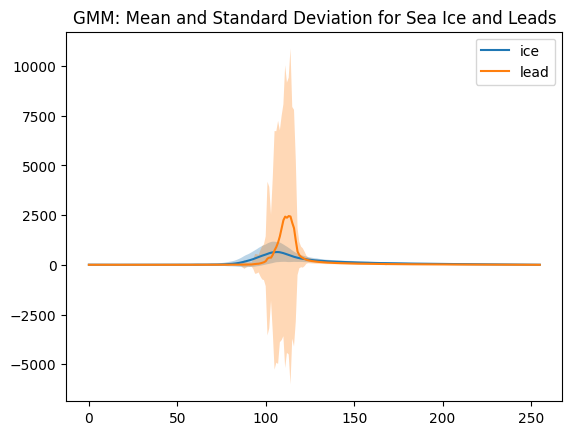

In [38]:
# mean and standard deviation for all echoes
mean_ice = np.mean(waves_cleaned[clusters_gmm==0],axis=0)
std_ice = np.std(waves_cleaned[clusters_gmm==0], axis=0)

plt.plot(mean_ice, label='ice')
plt.fill_between(range(len(mean_ice)), mean_ice - std_ice, mean_ice + std_ice, alpha=0.3)


mean_lead = np.mean(waves_cleaned[clusters_gmm==1],axis=0)
std_lead = np.std(waves_cleaned[clusters_gmm==1], axis=0)

plt.plot(mean_lead, label='lead')
plt.fill_between(range(len(mean_lead)), mean_lead - std_lead, mean_lead + std_lead, alpha=0.3)

plt.title('GMM: Mean and Standard Deviation for Sea Ice and Leads')
plt.legend()

#### Echo Waveforms by Class (Unnormalised)

To get a sense of the variation within each group, we can plot all recorded waveforms from the dataset, separated by their assigned class.
This helps us visually confirm key differences: leads tend to produce sharper, higher-return signals, while sea ice echoes are broader and generally lower in power.

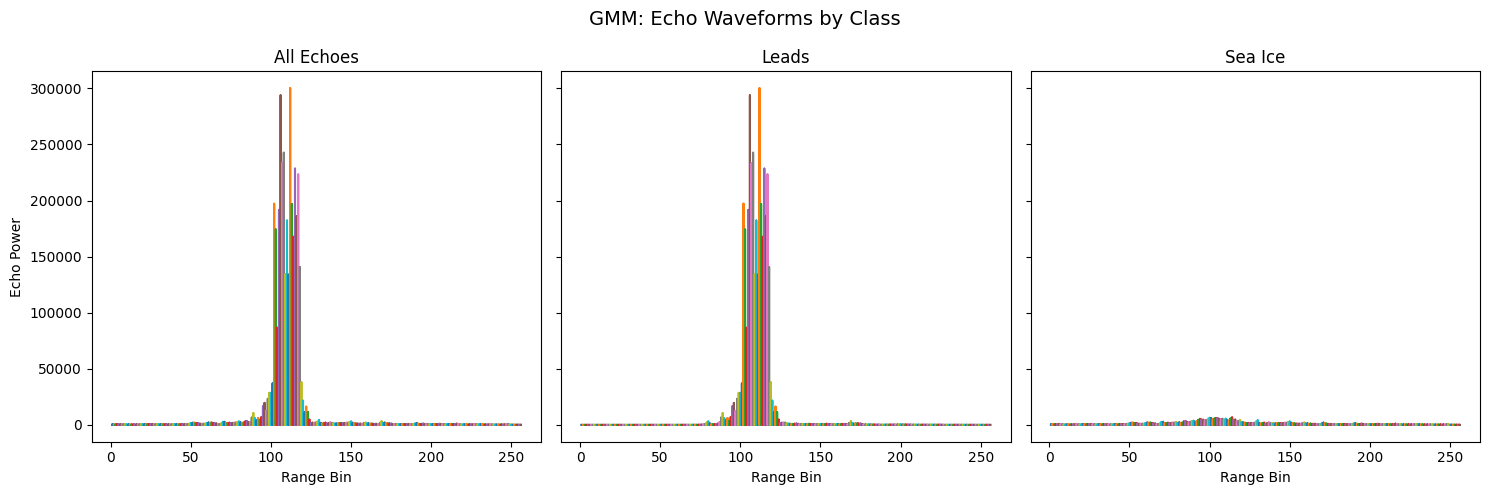

<Figure size 640x480 with 0 Axes>

In [49]:
# Create x values for each set
x_all = np.stack([np.arange(1, waves_cleaned.shape[1] + 1)] * waves_cleaned.shape[0])
x_leads = np.stack([np.arange(1, waves_cleaned[clusters_gmm == 1].shape[1] + 1)] * waves_cleaned[clusters_gmm == 1].shape[0])
x_ice = np.stack([np.arange(1, waves_cleaned[clusters_gmm == 0].shape[1] + 1)] * waves_cleaned[clusters_gmm == 0].shape[0])

# Create one figure with 3 subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle("GMM: Echo Waveforms by Class", fontsize=14)


# All echoes
axs[0].plot(x_all, waves_cleaned)
axs[0].set_title("All Echoes")
axs[0].set_xlabel("Range Bin")
axs[0].set_ylabel("Echo Power")

# Leads
axs[1].plot(x_leads, waves_cleaned[clusters_gmm == 1])
axs[1].set_title("Leads")
axs[1].set_xlabel("Range Bin")

# Sea ice
axs[2].plot(x_ice, waves_cleaned[clusters_gmm == 0])
axs[2].set_title("Sea Ice")
axs[2].set_xlabel("Range Bin")

plt.tight_layout()
plt.show()
plt.savefig("/content/drive/MyDrive/Earth Science/GEOL0069/Week 4/Figures/GMM_Echos_S3.jpg", dpi=300)


#### Echo Waveforms by Class (Normalised)
To better compare the **shape** of the echoes (rather than their absolute power), we can normalise each waveform by its own maximum.  
This highlights the differences in peak structure and spread between the two clusters more clearly.

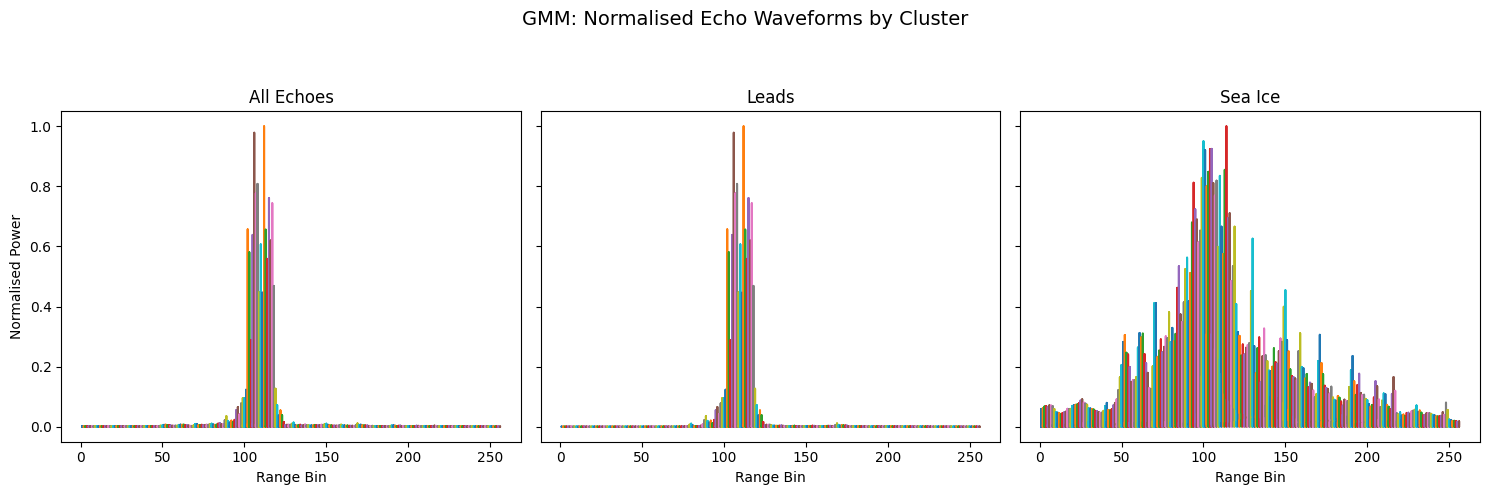

<Figure size 640x480 with 0 Axes>

In [50]:
# Define a normalisation function (global max for consistency)
def normalise_by_max(data):
    return data / np.max(data)

# Apply normalisation to each group
waves_cleaned_norm = normalise_by_max(waves_cleaned)
waves_leads_norm = normalise_by_max(waves_cleaned[clusters_gmm == 1])
waves_ice_norm = normalise_by_max(waves_cleaned[clusters_gmm == 0])

# Create x-axis values
x_all = np.stack([np.arange(1, waves_cleaned.shape[1] + 1)] * waves_cleaned.shape[0])
x_leads = np.stack([np.arange(1, waves_leads_norm.shape[1] + 1)] * waves_leads_norm.shape[0])
x_ice = np.stack([np.arange(1, waves_ice_norm.shape[1] + 1)] * waves_ice_norm.shape[0])

# Create figure with 3 subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
fig.suptitle("GMM: Normalised Echo Waveforms by Cluster", fontsize=14)

# Plot all echoes
axs[0].plot(x_all, waves_cleaned_norm)
axs[0].set_title("All Echoes")
axs[0].set_xlabel("Range Bin")
axs[0].set_ylabel("Normalised Power")

# Plot leads
axs[1].plot(x_leads, waves_leads_norm)
axs[1].set_title("Leads")
axs[1].set_xlabel("Range Bin")

# Plot sea ice
axs[2].plot(x_ice, waves_ice_norm)
axs[2].set_title("Sea Ice")
axs[2].set_xlabel("Range Bin")

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()
plt.savefig("/content/drive/MyDrive/Earth Science/GEOL0069/Week 4/Figures/GMM_Normalised_Echos_S3.jpg", dpi=300)

#### Scatter Plots by Cluster

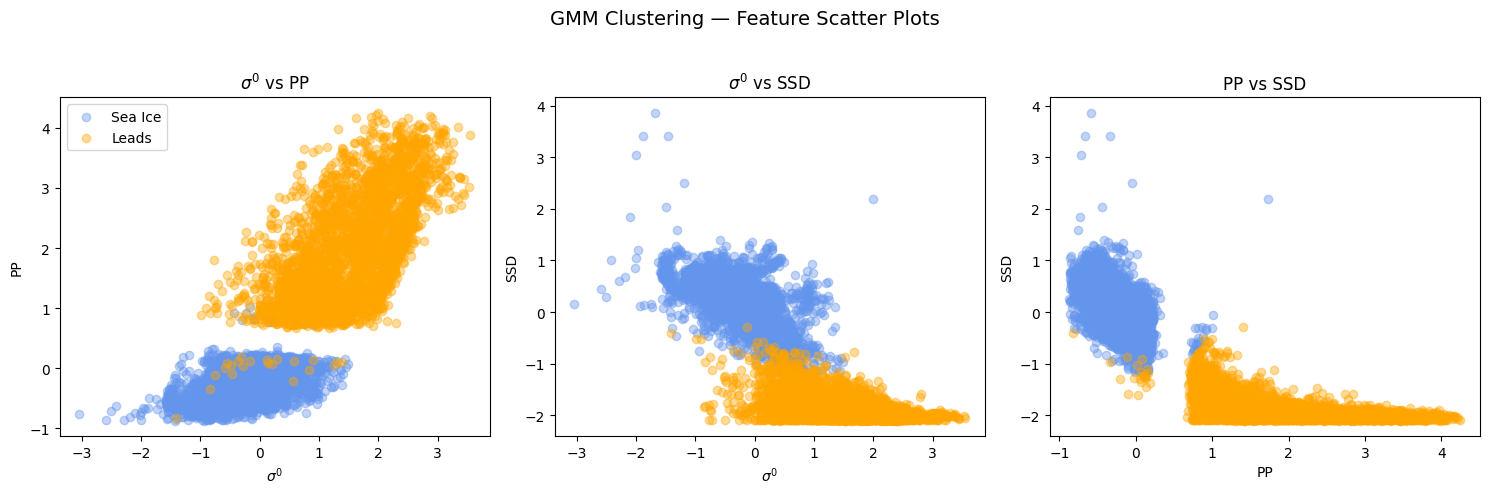

<Figure size 640x480 with 0 Axes>

In [51]:
colors = {0: "cornflowerblue", 1: "orange"}
labels = {0: "Sea Ice", 1: "Leads"}

# Set up figure and axes
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("GMM Clustering — Feature Scatter Plots", fontsize=14)

# Plot 1: σ₀ vs PP
for cluster in [0, 1]:
    mask = clusters_gmm == cluster
    axs[0].scatter(data_cleaned[mask, 0], data_cleaned[mask, 1],
                   color=colors[cluster], alpha=0.4, label=labels[cluster])
axs[0].set_xlabel(r"$\sigma^0$")
axs[0].set_ylabel("PP")
axs[0].set_title(r"$\sigma^0$ vs PP")
axs[0].legend()

# Plot 2: σ₀ vs SSD
for cluster in [0, 1]:
    mask = clusters_gmm == cluster
    axs[1].scatter(data_cleaned[mask, 0], data_cleaned[mask, 2],
                   color=colors[cluster], alpha=0.4)
axs[1].set_xlabel(r"$\sigma^0$")
axs[1].set_ylabel("SSD")
axs[1].set_title(r"$\sigma^0$ vs SSD")

# Plot 3: PP vs SSD
for cluster in [0, 1]:
    mask = clusters_gmm == cluster
    axs[2].scatter(data_cleaned[mask, 1], data_cleaned[mask, 2],
                   color=colors[cluster], alpha=0.4)
axs[2].set_xlabel("PP")
axs[2].set_ylabel("SSD")
axs[2].set_title("PP vs SSD")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
plt.savefig("/content/drive/MyDrive/Earth Science/GEOL0069/Week 4/Figures/feature_scatter_gmm.jpg", dpi=300)

### Echo Classification Using K-Means

Optional: Repeat the process using K-Means clustering which *is* a simpler algorithm that assigns each data point to the nearest cluster centre without considering uncertainty.  
This can be a useful baseline for comparison with GMM results.

## Assessment: Final Classification Results

In this section, we evaluate the performance of our echo classification using the Gaussian Mixture Model (GMM). We begin by computing the average echo shape and its standard deviation for each class, then compare our predicted labels to the ESA dataset using a confusion matrix.

### Average Echo Shape & Standard Deviation (Aligned)

To ensure meaningful averaging, the waveforms were first aligned using a reference waveform from each class. This compensates for small shifts in peak position.

In [46]:
def align_waveforms(waves: np.ndarray, ref: np.ndarray) -> np.ndarray:
    """Shift each waveform so its max aligns with the reference peak."""
    peak = ref.argmax()
    aligned = np.empty_like(waves)
    for i, w in enumerate(waves):
        shift = peak - w.argmax()
        aligned[i] = np.roll(w, shift)
    return aligned

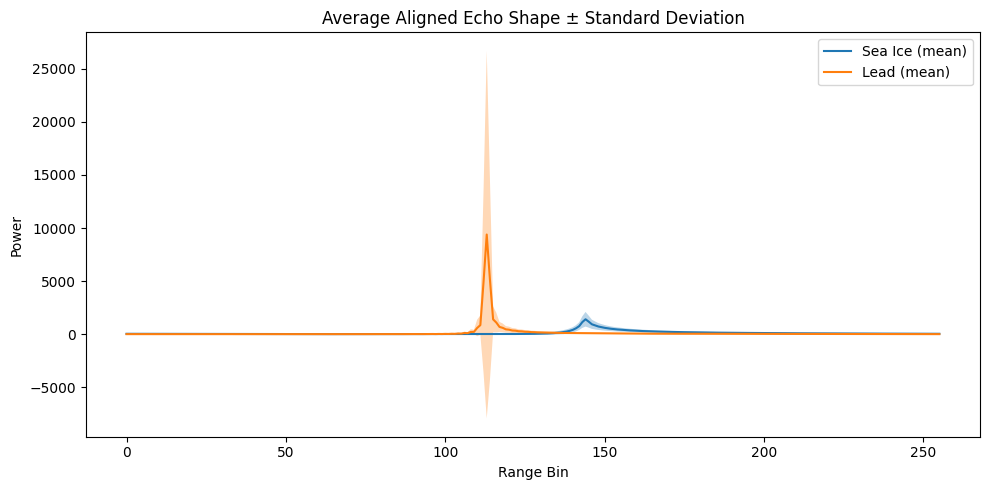

<Figure size 640x480 with 0 Axes>

In [52]:
# Align waveforms by class
aligned_gmm_ice = align_waveforms(waves_cleaned[clusters_gmm == 0], waves_cleaned[clusters_gmm == 0][0])
aligned_gmm_lead = align_waveforms(waves_cleaned[clusters_gmm == 1], waves_cleaned[clusters_gmm == 1][0])

# Compute mean and standard deviation
mean_ice = np.mean(aligned_gmm_ice, axis=0)
std_ice = np.std(aligned_gmm_ice, axis=0)

mean_lead = np.mean(aligned_gmm_lead, axis=0)
std_lead = np.std(aligned_gmm_lead, axis=0)

# Plot mean ± std
plt.figure(figsize=(10, 5))
plt.plot(mean_ice, label="Sea Ice (mean)")
plt.fill_between(range(len(mean_ice)), mean_ice - std_ice, mean_ice + std_ice, alpha=0.3)

plt.plot(mean_lead, label="Lead (mean)")
plt.fill_between(range(len(mean_lead)), mean_lead - std_lead, mean_lead + std_lead, alpha=0.3)

plt.title("Average Aligned Echo Shape ± Standard Deviation")
plt.xlabel("Range Bin")
plt.ylabel("Power")
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig("/content/drive/MyDrive/Earth Science/GEOL0069/Week 4/Figures/echo_mean_std.jpg", dpi=300)

### Compare GMM Classification with ESA Labels

To validate our clustering, we compare our GMM-based labels with the ESA official classification (surf_type_class_20_ku).
We do this using a confusion matrix and a classification report showing precision, recall, and F1 scores.

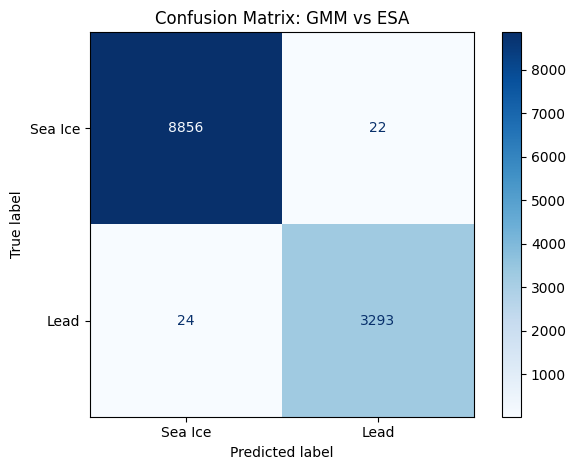

Classification Report:

              precision    recall  f1-score   support

     Sea Ice       1.00      1.00      1.00      8878
        Lead       0.99      0.99      0.99      3317

    accuracy                           1.00     12195
   macro avg       1.00      1.00      1.00     12195
weighted avg       1.00      1.00      1.00     12195



<Figure size 640x480 with 0 Axes>

In [53]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# ESA flags: 1 = sea ice, 2 = lead → shift to 0 and 1
true_labels = flag_cleaned - 1
predicted_labels = clusters_gmm

# Confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Sea Ice", "Lead"])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix: GMM vs ESA")
plt.tight_layout()
plt.show()

# Print classification report
print("Classification Report:\n")
print(classification_report(true_labels, predicted_labels, target_names=["Sea Ice", "Lead"]))
plt.savefig("/content/drive/MyDrive/Earth Science/GEOL0069/Week 4/Figures/confusion_matrix.jpg", dpi=300)